<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/LABORATORIO_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laboratorio 1: Regresión Lineal Múltiple**


Estudiante: Nelva Adalit Mora
Barrionuevo

Carrera: Ingeniería de Sistemas

Dataset: Appliances Energy Prediction (KAG_energydata_complete.csv)
link: https://www.kaggle.com/datasets/loveall/appliances-energy-prediction

Descripción del Problema:Este laboratorio implementa un modelo de Regresión Lineal Múltiple para predecir el consumo de energía de los electrodomésticos en una vivienda domótica (Smart Home). Se utiliza un dataset de sensores y clima con 30 variables numéricas tras el preprocesamiento temporal ($n=30$) para estimar la carga eléctrica en Wh ($y$). El dataset procesado contiene 19,735 registros ($m > 10000$), cumpliendo rigurosamente con los requisitos de complejidad y escala estipulados para el entrenamiento del modelo mediante el algoritmo de Descenso por el Gradiente.

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

In [15]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [16]:
# Cargar el dataset de Smart Home
ruta = '/content/gdrive/MyDrive/SIS420IA/KAG_energydata_complete.csv'
df = pd.read_csv(ruta)

# PREPROCESAMIENTO INTELIGENTE (Feature Engineering)
# Convertimos la columna de texto 'date' a formato de fecha
df['date'] = pd.to_datetime(df['date'])

# Extraemos la información del texto y la volvemos números
df['mes'] = df['date'].dt.month
df['dia'] = df['date'].dt.day
df['hora'] = df['date'].dt.hour

# Borramos la fecha original en texto
df = df.drop('date', axis=1)

# Aseguramos que no haya nulos y convertimos todo a float
df = df.dropna().astype(float)

# Separar X (Todas las características) e y (Consumo de Electrodomésticos)
y = df['Appliances'].values
X = df.drop('Appliances', axis=1).values

m = y.size
print("Cantidad de datos (m):", m)
print("Cantidad de características (n):", X.shape[1])

# Muestra rápida
print('-'*50)
print('{:>10s}{:>10s}{:>10s}{:>15s}'.format('X[:,0]', 'X[:,1]', 'X[:,2]', 'y (Consumo)'))
for i in range(10):
    print('{:10.2f}{:10.2f}{:10.2f}{:15.2f} Wh'.format(X[i, 0], X[i, 1], X[i, 2], y[i]))

# Muestra rápida final en formato matriz
print('-'*50)
print('{:>10s}{:>10s}{:>10s}{:>15s}'.format('X[:,0]', 'X[:,1]', 'X[:,2]', 'y (Consumo)'))
for i in range(5):
    print('{:10.2f}{:10.2f}{:10.2f}{:15.2f} Wh'.format(X[i, 0], X[i, 1], X[i, 2], y[i]))

Cantidad de datos (m): 19735
Cantidad de características (n): 30
--------------------------------------------------
    X[:,0]    X[:,1]    X[:,2]    y (Consumo)
     30.00     19.89     47.60          60.00 Wh
     30.00     19.89     46.69          60.00 Wh
     30.00     19.89     46.30          50.00 Wh
     40.00     19.89     46.07          50.00 Wh
     40.00     19.89     46.33          60.00 Wh
     40.00     19.89     46.03          50.00 Wh
     50.00     19.89     45.77          60.00 Wh
     50.00     19.86     45.56          60.00 Wh
     40.00     19.79     45.60          60.00 Wh
     40.00     19.86     46.09          70.00 Wh
--------------------------------------------------
    X[:,0]    X[:,1]    X[:,2]    y (Consumo)
     30.00     19.89     47.60          60.00 Wh
     30.00     19.89     46.69          60.00 Wh
     30.00     19.89     46.30          50.00 Wh
     40.00     19.89     46.07          50.00 Wh
     40.00     19.89     46.33          60.00 Wh


In [17]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    sigma[sigma == 0] = 1 # Evitar división por cero

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Normalizamos los datos
X_norm, mu, sigma = featureNormalize(X)

print('Datos normalizados (primeras 3 filas):')
print(X_norm[:3, :])

# Añadimos la columna de unos (intersección o bias)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print("\nX con la columna de unos (primeras 3 filas):")
print(X[:3, :])

Datos normalizados (primeras 3 filas):
[[ 3.30126384 -1.11864475  1.84382063 -0.52041138  1.07368343 -1.23506343
   1.68612997 -0.90821667  1.50643758 -1.31490324  0.47116038 -0.14519618
   0.95179837 -1.45364639  1.21986131 -1.95750878  1.14157236 -1.21732362
   0.95813624 -0.15264674 -2.97632767  0.82208042  1.20769354  2.09159642
   0.3669753  -0.80797358 -0.80797358 -1.56936931 -0.59845459  0.79430442]
 [ 3.30126384 -1.11864475  1.61680671 -0.52041138  1.05709748 -1.23506343
   1.70456601 -0.90821667  1.6045285  -1.31490324  0.47116038 -0.17694121
   0.94559165 -1.45364639  1.2068254  -1.95750878  1.13455378 -1.20077824
   0.96536273 -0.17458781 -2.96281279  0.82208042  1.07170342  1.76658397
   0.34313479 -0.44024015 -0.44024015 -1.56936931 -0.59845459  0.79430442]
 [ 3.30126384 -1.11864475  1.51795932 -0.52041138  1.03354953 -1.23506343
   1.74860768 -0.94411453  1.58091757 -1.31490324  0.45896769 -0.22182211
   0.91648425 -1.45364639  1.18205717 -1.95750878  1.10903167 -1.233868

In [18]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()

    J_history = []
    P_history = [] # <-- NUEVO: Aquí guardaremos la precisión

    # Calculamos la varianza total (necesaria para la precisión R^2)
    ss_tot = np.sum(np.square(y - np.mean(y)))

    for i in range(num_iters):
        # 1. Actualizamos theta
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)

        # 2. Guardamos el costo
        J_history.append(computeCostMulti(X, y, theta))

        # 3. NUEVO: Calculamos y guardamos la precisión (%)
        predicciones = np.dot(X, theta)
        ss_res = np.sum(np.square(predicciones - y))
        r2 = 1 - (ss_res / ss_tot)
        precision_porcentaje = r2 * 100
        P_history.append(precision_porcentaje)

    return theta, J_history, P_history

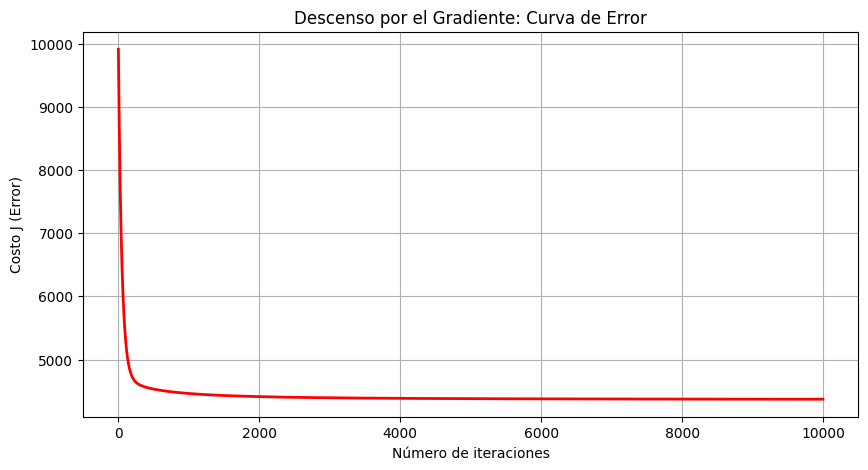

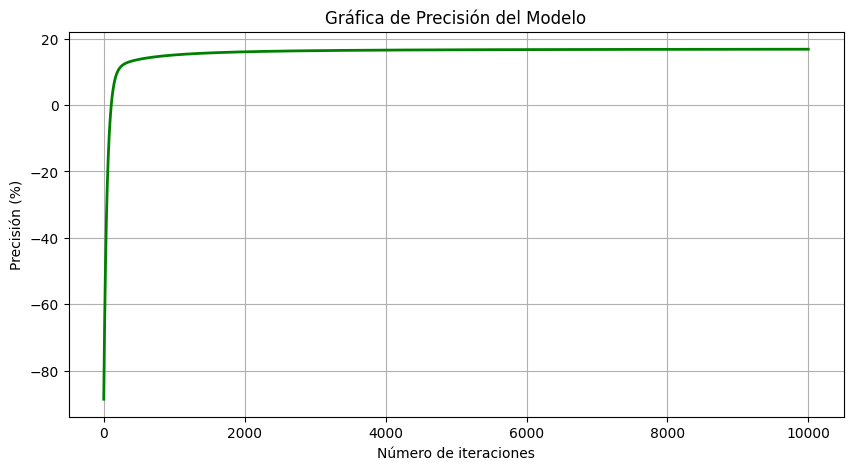

Theta calculado por el descenso por el gradiente:
 [ 97.6949582   15.33597684 -12.45500863  52.7661807  -28.49331526
 -45.13323533  55.4786637   12.58389527  -7.12837094  -7.21289501
  -0.86269609   0.43195192  33.15053525  -0.55930794   1.37997004
  -7.7645646   15.24927495 -19.27380097 -19.16374457  -2.62406352
 -16.57263123   1.04160465   6.17287424   3.97994828   1.53808728
  -1.7692766   -0.30164734  -0.30164734 -17.92553473  -0.97686481
   6.6962518 ]
Precisión final alcanzada: 16.82 %
------------------------------------------------------
El consumo de energía predecido es: 177.32 Wh


In [19]:
# 1. Configurar hiperparámetros
alpha = 0.01
num_iters = 10000

# Inicializamos theta con 31 ceros
theta = np.zeros(31)

# Entrenamos el modelo y recibimos las dos listas (Costo y Precisión)
theta, J_history, P_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# 2. GRAFICAR LA CONVERGENCIA DEL COSTO (Error)
pyplot.figure(figsize=(10, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='red')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J (Error)')
pyplot.title('Descenso por el Gradiente: Curva de Error')
pyplot.grid(True)
pyplot.show()

# 3. NUEVO: GRAFICAR LA PRECISIÓN DEL MODELO
pyplot.figure(figsize=(10, 5))
pyplot.plot(np.arange(len(P_history)), P_history, lw=2, color='green')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Precisión (%)')
pyplot.title('Gráfica de Precisión del Modelo')
pyplot.grid(True)
pyplot.show()

print('Theta calculado por el descenso por el gradiente:\n', theta)
print('Precisión final alcanzada: {:.2f} %'.format(P_history[-1]))

# 4. PREDICCIÓN CON UN REGISTRO NUEVO DE PRUEBA
X_array = [1.0, 40.0, 19.89, 46.33, 19.2, 44.53, 19.79, 45.0, 18.89, 45.53, 17.2, 55.09,
           6.36, 84.89, 17.2, 41.23, 18.1, 48.59, 17.0, 45.4, 6.13, 733.9, 92.0, 5.66,
           47.66, 4.9, 10.08, 10.08, 1.0, 11.0, 18.0]

X_array[1:31] = (X_array[1:31] - mu) / sigma
consumo = np.dot(X_array, theta)

print('------------------------------------------------------')
print('El consumo de energía predecido es: {:.2f} Wh'.format(consumo))